## Check frequency functions

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import sys

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.insert(0, parent_dir)
from utils import quickread

print(parent_dir)
sys.path.pop(0)  # Removes the parent_dir from sys.path
current_dir = os.getcwd()

/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src


In [2]:
def compute_empirical_freqs(Z: np.ndarray, W: np.ndarray, q: int) -> np.ndarray:
    """
    Compute empirical weighted frequencies.
    Z : ndarray of shape (N, M) with entries in [1..q]
    W : ndarray of shape (M,)
    q : alphabet size
    Returns: ndarray of shape (q, N)
    """
    N, M = Z.shape
    if W is None:
        W = np.ones(M) # divide by M at the end
        W = W / M
    else: 
        W = W / W.sum()  # Normalize weights to sum to 1
    # one-hot: (N, M, q)
    Z0 = Z - 1  # shift to 0-based indexing --- IGNORE ---
    one_hot = np.eye(q, dtype=float)[Z0]

    # Multiply weights (broadcast W along N and q)
    weighted = one_hot * W[None, :, None]  # (N, M, q)

    # Sum over sequences (axis=1), result shape (N, q)
    f = weighted.sum(axis=1).T  # (q, N)

    return f

In [7]:
older_dir = os.path.abspath(os.path.join(current_dir, '..', '..', '..','..'))
Z,W = quickread(older_dir + '/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta')

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.3717963398737716
Computed theta: 0.32706077752482543


100%|██████████| 14502/14502 [00:17<00:00, 827.11it/s] 

3265.70225762244


In [13]:
f = compute_empirical_freqs(Z, W, q=21)
print(f.shape)
f_flat = f.flatten()
print(f_flat.shape)

(21, 63)
(1323,)


In [20]:
# load sequences from /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST/jdoms_J_py/gen_3000_3000_1.npy
sequences = np.load('/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST/jdoms_J_py/gen_3000_3000_1.npy')
print(sequences.shape)
f_gen = compute_empirical_freqs(sequences.T, None, q=21)
f_gen_flat = f_gen.flatten()
print(f_gen.shape)

(3000, 63)
(21, 63)


In [31]:
# load from test sequences
Z_test, W_test = quickread(older_dir + '/DataAttentionDCA/jdoms/jdoms_bacteria_test2.fasta')

Total sequences read: 3739
Sequences after filtering: 3739
Sampling 100000 pairs out of 6988191 total pairs.
Mean fraction of identical positions (sampled): 0.37077222222222217
Computed theta: 0.327964158887607


100%|██████████| 3739/3739 [00:00<00:00, 6578.07it/s]

1325.4984819766414


In [32]:
print(Z_test.shape)
f_test = compute_empirical_freqs(Z_test, None, q=21)
f_test_flat = f_test.flatten()
print(f_test.shape)

(63, 3739)
(21, 63)


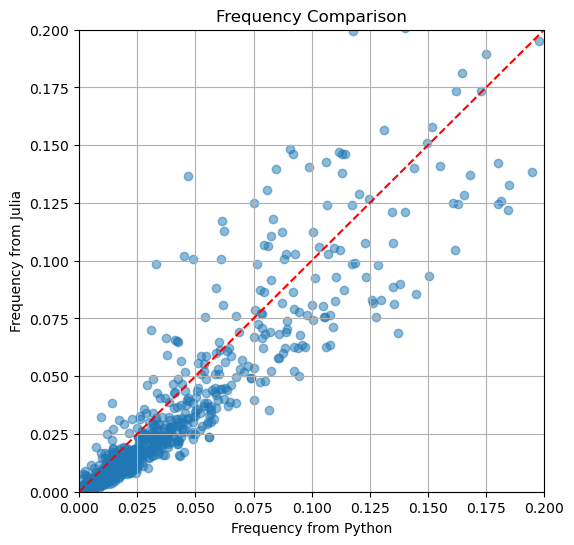

In [37]:
# freq-freq plot
plt.figure(figsize=(6,6))
plt.scatter(f_flat, f_test_flat, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')
plt.plot([0, 0.2], [0, 0.2], 'r--')  # y=x line
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.grid()
plt.show()